In [823]:
import pandas as pd
from sklearn import model_selection
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, auc, roc_curve, roc_auc_score
from seaborn import heatmap

# Task1: Acquire, preprocess, and analyze the data

In [824]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

## Breast Cancer Dataset:

### fetch the dataset:

In [825]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
bc_X = breast_cancer_wisconsin_diagnostic.data.features
bc_y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

### Check for missing variables:

In [826]:
print(bc_X.shape)
print(bc_y.shape)

# Check to see if there are missing features or target values
print(bc_X.isnull().sum())
print(bc_y.isnull().sum())

(569, 30)
(569, 1)
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64
Diagnosis    0
dtype: int64


### Standardize the target values:

In [827]:
#Convert the predictions to either 0 or 1
bc_y = bc_y.replace({'B': 0, 'M': 1})

<ipython-input-827-f1a7d0f29adb>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bc_y = bc_y.replace({'B': 0, 'M': 1})


### Split the dataset

In [828]:
# Check to see if the datapoints are classified proportionally:
print(bc_y.value_counts)
print(bc_y.value_counts(normalize=True))

#Divide the datpoints to train, test and validation (70, 15, 15)
# Since the classes are not divided equally we use the stratify to selects points proportianlly to avoid bias
X_train_bc, X_temp_bc, y_train_bc, y_temp_bc = train_test_split(bc_X, bc_y, test_size=0.3, random_state=42, stratify=bc_y)
X_val_bc, X_test_bc, y_val_bc, y_test_bc = train_test_split(X_temp_bc, y_temp_bc, test_size=0.5, random_state=42, stratify=y_temp_bc)


<bound method DataFrame.value_counts of      Diagnosis
0            1
1            1
2            1
3            1
4            1
..         ...
564          1
565          1
566          1
567          1
568          0

[569 rows x 1 columns]>
Diagnosis
0            0.627417
1            0.372583
Name: proportion, dtype: float64


### Standardize the features:

In [829]:
# We divide the dataset before standardize them to avoid data leakage:
scaler_bc = StandardScaler()
# Train:
X_train_bc_scaled = pd.DataFrame(scaler_bc.fit_transform(X_train_bc), columns=bc_X.columns, index=X_train_bc.index)
# Valid:
X_val_bc_scaled = pd.DataFrame(scaler_bc.transform(X_val_bc), columns=bc_X.columns, index=X_val_bc.index)
# Test:
X_test_bc_scaled = pd.DataFrame(scaler_bc.transform(X_test_bc), columns=bc_X.columns, index=X_test_bc.index)

### compute feature importance

In [830]:
# Compute simple regression coefficients using matrix computation
N_bc = X_train_bc_scaled.shape[0]
w_bc = np.dot(X_train_bc_scaled.values.T, y_train_bc.values) / N_bc
# w_bc_t0 = np.dot(X_train_bc_scaled.values.T, (1 - y_train_bc.values)) / N_bc

#shape: Dx1
print(w_bc.shape)
# print(w_bc_t0.shape)


(30, 1)


### Rank and plot features:

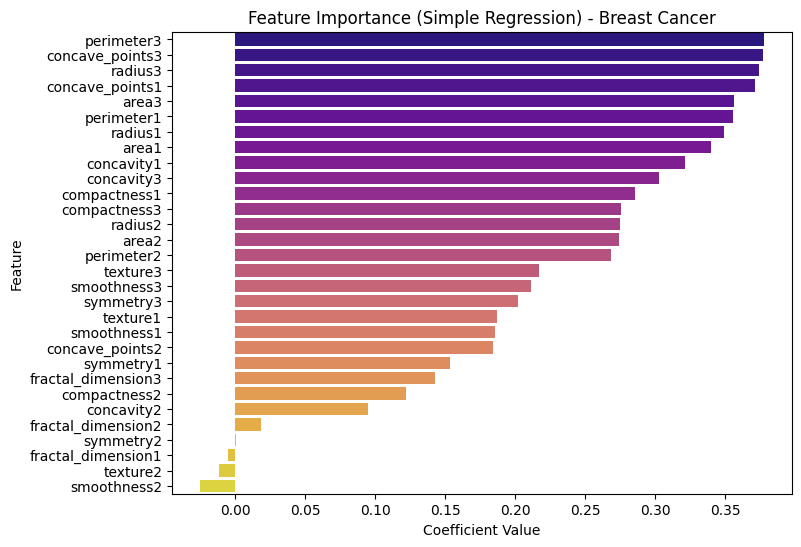

In [831]:
# get the coefficients for the target value 1 (cancer) in decreasing order:
df_coef_bc = pd.DataFrame({
    'Feature': bc_X.columns,
    'Coefficient': w_bc.flatten()
}).sort_values(by='Coefficient', ascending=False)

# Plot horizontal bar plot for target value 1 (cancer)
plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=df_coef_bc, hue='Feature', palette='plasma', legend=False)
plt.title('Feature Importance (Simple Regression) - Breast Cancer')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()



# (This part can/should be removed????????!!!!!!) Should we have two barplots for binary?

# # get the coefficients for the target value 1 (cancer) in decreasing order:
# df_coef_bc_t0 = pd.DataFrame({
#     'Feature': bc_X.columns,
#     'Coefficient': w_bc_t0.flatten()
# }).sort_values(by='Coefficient', ascending=False)

# # Plot horizontal bar plot for target value 1 (cancer)
# plt.figure(figsize=(8, 6))
# sns.barplot(x='Coefficient', y='Feature', data=df_coef_bc_t0, hue='Feature', palette='plasma', legend=False)
# plt.title('Feature Importance (Simple Regression) - Breast Cancer')
# plt.xlabel('Coefficient Value')
# plt.ylabel('Feature')
# plt.show()

### Remove any unnecessary features from the dataset: (NOT DONE YET)

## Wine Recognition Dataset:

### Fetch the dataset:

In [832]:
# fetch dataset
wine = fetch_ucirepo(id=109)

# data (as pandas dataframes)
X_wine = wine.data.features
y_wine = wine.data.targets

# metadata
print(wine.metadata)

# variable information
print(wine.variables)

print(X_wine.shape)
print(y_wine.shape)


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

### Check for the missing variables:

In [833]:
print(X_wine.shape)
print(y_wine.shape)

# Check to see if there are missing features or target values
print(X_wine.isnull().sum())
print(y_wine.isnull().sum())

# check the different target values:
print(y_wine.value_counts())

(178, 13)
(178, 1)
Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
dtype: int64
class    0
dtype: int64
class
2        71
1        59
3        48
Name: count, dtype: int64


### Standardize the target values:

In [834]:
print(y_wine['class'].unique())
# One hot encoing
y_wine_onehotencoded = pd.get_dummies(y_wine, columns=['class'])
print(y_wine_onehotencoded.shape)
print(y_wine_onehotencoded.head())

[1 2 3]
(178, 3)
   class_1  class_2  class_3
0     True    False    False
1     True    False    False
2     True    False    False
3     True    False    False
4     True    False    False


### Split the dataset:

In [835]:
# Check to see if the datapoints are classified proportionally:
print(y_wine.value_counts)
print(y_wine.value_counts(normalize=True))

# Divide the datpoints to train, test and validation (70, 15, 15)
# Since the classes are not divided equally we use the stratify to selects points proportianlly to avoid bias
X_train_wine, X_temp_wine, y_train_wine, y_temp_wine = train_test_split(X_wine, y_wine_onehotencoded, test_size=0.5, random_state=42, stratify=y_wine_onehotencoded)
X_val_wine, X_test_wine, y_val_wine, y_test_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.5, random_state=42, stratify=y_temp_wine)


<bound method DataFrame.value_counts of      class
0        1
1        1
2        1
3        1
4        1
..     ...
173      3
174      3
175      3
176      3
177      3

[178 rows x 1 columns]>
class
2        0.398876
1        0.331461
3        0.269663
Name: proportion, dtype: float64


###Standardize the features:

In [836]:
# We divide the dataset before standardize them to avoid data leakage:
scaler_wine = StandardScaler()
# Train:
X_train_wine_scaled = pd.DataFrame(scaler_wine.fit_transform(X_train_wine), columns=X_wine.columns, index=X_train_wine.index)
# Valid:
X_val_wine_scaled = pd.DataFrame(scaler_wine.transform(X_val_wine), columns=X_wine.columns, index=X_val_wine.index)
# Test:
X_test_wine_scaled = pd.DataFrame(scaler_wine.transform(X_test_wine), columns=X_wine.columns, index=X_test_wine.index)

###compute feature importance

In [837]:
# Compute simple regression coefficients using matrix computation
N_wine = X_train_wine_scaled.shape[0]
W_wine = np.dot(X_train_wine_scaled.values.T, y_train_wine.values) / N_wine

#shape: Dx3
print(W_wine.shape)

(13, 3)


In [838]:
print(N_wine)
print(W_wine)

89
[[ 0.33673206 -0.37660235  0.03987029]
 [-0.09922946 -0.18733885  0.28656831]
 [ 0.08673256 -0.13738988  0.05065732]
 [-0.24418732  0.10014535  0.14404197]
 [ 0.13033269 -0.08328239 -0.04705031]
 [ 0.29277216 -0.04183213 -0.25094003]
 [ 0.32761856  0.01793936 -0.34555792]
 [-0.22654296  0.01179142  0.21475153]
 [ 0.12730336  0.09816199 -0.22546535]
 [ 0.10225597 -0.34953328  0.24727731]
 [ 0.13929903  0.18537536 -0.32467439]
 [ 0.28033517  0.06551461 -0.34584977]
 [ 0.39724583 -0.29178408 -0.10546175]]


### Rank and Plot features:

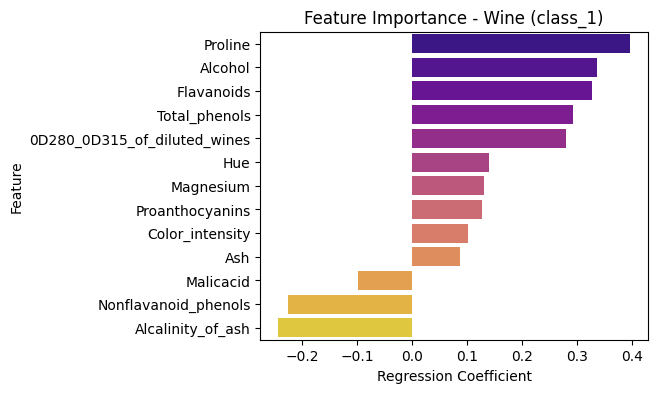

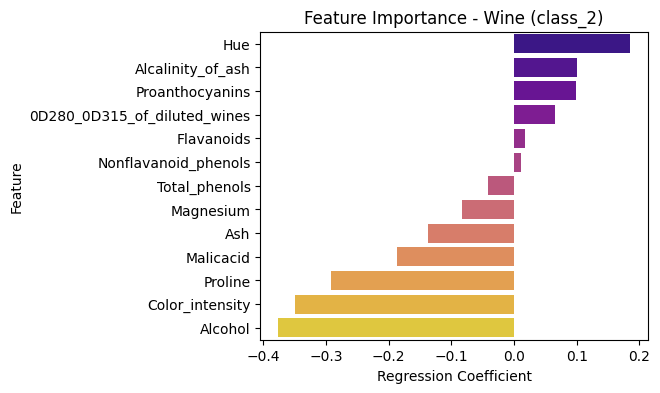

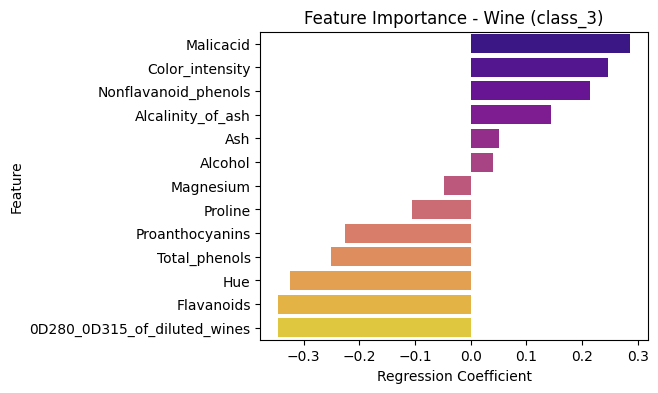

In [839]:
# Iterate through each class:
for i, class_ in enumerate(y_wine_onehotencoded.columns):
  # get the coefficients for each class in decreasing order:
  coefs = W_wine[:, i]
  df_coef_wine = pd.DataFrame({
      'Feature': X_wine.columns,
      'Coefficient': coefs
  }).sort_values(by='Coefficient', ascending=False)

  # Plot the features per class:
  plt.figure(figsize=(5, 4))
  sns.barplot(x='Coefficient', y='Feature', data=df_coef_wine, hue='Feature', palette='plasma', legend=False)
  plt.title(f'Feature Importance - Wine ({class_})')
  plt.xlabel('Regression Coefficient')
  plt.ylabel('Feature')
  plt.show()



### Remove any unnecessary features from the dataset: (NOT DONE YET)

# Task 2: Implement linear regression models

In [840]:
# Define helper functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)

class LinearRegression:
  def __init__(self):
    # the weight vector for univariate (w = (X⊤X)−1X⊤y) and matrix for multivariate regression (W = (X⊤X)−1X⊤Y)
    self.weights = None

  def fit(self, X, y):
    # Add bias term to the features
    X_biased = np.hstack([np.ones((X.shape[0], 1)), X])
    # closed form solution for weights:
    w = (np.linalg.inv(X_biased.T @ X_biased)) @ (X_biased.T @ y)
    self.weights = w
    return self.weights

  def predict(self, X):
    # Add bias term to the features
    X_biased = np.hstack([np.ones((X.shape[0], 1)), X])
    pred = np.dot(X_biased, self.weights)
    return pred


  # This is not working but would be nice to fix it if we got time other wise just remove it and remove the following commented cell after this:
  # def accuracy_cal(self, X, y, theta = 0.5):
  #   y_pred = self.predict(X)
  #   y_pred_class = (y_train_pred >= theta).astype(int)
  #   accuracy = accuracy_score(y, y_pred_class)
  #   return accuracy


In [841]:
# Binary Model:
binary_model = LinearRegression()
binary_weights = binary_model.fit(X_train_bc_scaled, y_train_bc)

y_train_pred = binary_model.predict(X_train_bc_scaled)
y_train_pred_class = (y_train_pred >= 0.5).astype(int)
binary_accuracy_train = accuracy_score(y_train_bc, y_train_pred_class)

y_val_pred = binary_model.predict(X_val_bc_scaled)
y_val_pred_class = (y_val_pred >= 0.5).astype(int)
binary_accuracy_val = accuracy_score(y_val_bc, y_val_pred_class)

y_test_pred = binary_model.predict(X_test_bc_scaled)
y_test_pred_class = (y_test_pred >= 0.5).astype(int)
binary_accuracy_test = accuracy_score(y_test_bc, y_test_pred_class)

print("Training Accuracy for Binary Classification:", binary_accuracy_train)
print("Validation Accuracy for Binary Classification:", binary_accuracy_val)
print("Test Accuracy for Binary Classification:", binary_accuracy_test)

Training Accuracy for Binary Classification: 0.964824120603015
Validation Accuracy for Binary Classification: 0.9647058823529412
Test Accuracy for Binary Classification: 0.9883720930232558


In [842]:
# Binary Model with sigmoid:
binary_model = LinearRegression()
binary_weights = binary_model.fit(X_train_bc_scaled, y_train_bc)

# Get predictions (raw continuous outputs)
y_train_pred_raw = binary_model.predict(X_train_bc_scaled.values)
y_val_pred_raw   = binary_model.predict(X_val_bc_scaled.values)
y_test_pred_raw  = binary_model.predict(X_test_bc_scaled.values)

# Convert raw predictions to probabilities using sigmoid
y_train_prob = sigmoid(y_train_pred_raw)
y_val_prob   = sigmoid(y_val_pred_raw)
y_test_prob  = sigmoid(y_test_pred_raw)

# Convert probabilities to binary predictions (threshold = 0.5)
y_train_pred_class = (y_train_prob >= 1).astype(int)
y_val_pred_class   = (y_val_prob >= 1).astype(int)
y_test_pred_class  = (y_test_prob >= 1).astype(int)

# Calculate Accuracy
binary_accuracy_train = accuracy_score(y_train_bc, y_train_pred_class)
binary_accuracy_val   = accuracy_score(y_val_bc, y_val_pred_class)
binary_accuracy_test  = accuracy_score(y_test_bc, y_test_pred_class)

print(y_test_pred_raw)
print("Binary Linear Regression Model:")
print("Training Accuracy:", binary_accuracy_train)
print("Validation Accuracy:", binary_accuracy_val)
print("Test Accuracy:", binary_accuracy_test)

# Calculate AUROC on test set (using probabilities)
binary_auroc_test = roc_auc_score(y_test_bc, y_test_prob)
print("Test AUROC:", binary_auroc_test)

[[ 1.25303629]
 [-0.11552972]
 [-0.17648705]
 [-0.23970807]
 [ 0.13862481]
 [ 0.68887553]
 [-0.06069685]
 [ 1.14522358]
 [-0.13919007]
 [ 0.03364908]
 [ 0.19240876]
 [-0.32779591]
 [ 0.54945242]
 [ 0.01626813]
 [-0.18183686]
 [-0.12261859]
 [-0.08943101]
 [ 0.5779121 ]
 [-0.461869  ]
 [ 0.0374172 ]
 [ 0.91658342]
 [ 0.85274081]
 [ 1.25602561]
 [ 0.46376225]
 [ 0.39539838]
 [ 0.88001889]
 [ 1.17506039]
 [ 0.98610177]
 [ 1.16231249]
 [ 0.5793751 ]
 [ 1.17746788]
 [ 0.07402691]
 [ 0.12840867]
 [ 0.97670348]
 [ 0.23272867]
 [ 0.89647072]
 [ 0.00922828]
 [ 0.71286714]
 [ 0.35304293]
 [ 0.80832156]
 [ 0.52524308]
 [-0.05398488]
 [-0.15071045]
 [ 0.05076769]
 [ 0.27671362]
 [-0.20724402]
 [ 0.04948668]
 [ 0.50372338]
 [ 0.57176633]
 [ 0.12115952]
 [ 0.04557178]
 [ 0.3731662 ]
 [-0.24562732]
 [ 1.26091998]
 [-0.07844239]
 [ 0.97137309]
 [ 0.63681865]
 [ 0.50391618]
 [-0.29137073]
 [-0.15060871]
 [-0.06568648]
 [-0.03228039]
 [ 1.13092039]
 [ 0.61340716]
 [-0.10681706]
 [ 0.20876435]
 [ 0.05768

Number of Features: 30
Number of Coefficients: (31, 1)


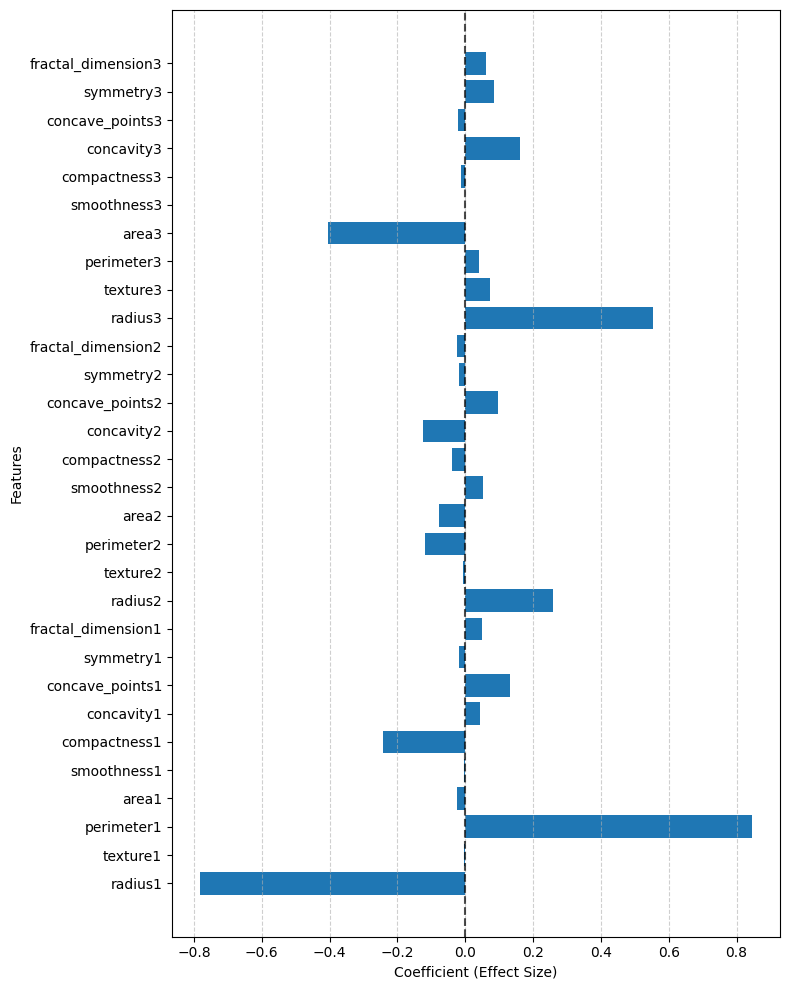

In [843]:
#coefficients effect size barplot
print(f"Number of Features: {len(X_train_bc.columns)}")
print(f"Number of Coefficients: {binary_weights.shape}")

effect_size = pd.DataFrame({
    "Feature": X_train_bc.columns,  # Feature names
    "Coefficient": binary_weights.to_numpy().flatten()[1:]  # Corresponding effect sizes
})

plt.figure(figsize=(8, 10))
plt.barh(effect_size["Feature"], effect_size["Coefficient"], align='center')
plt.xlabel("Coefficient (Effect Size)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)  # Reference line at zero
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [844]:
# Multi-Class Classification:
multiclass_model = LinearRegression()
multiclass_weights = multiclass_model.fit(X_train_wine_scaled, y_train_wine)

# Get the predictions:
Y_train_pred = multiclass_model.predict(X_train_wine_scaled)
Y_valid_pred = multiclass_model.predict(X_val_wine_scaled)
Y_test_pred = multiclass_model.predict(X_test_wine_scaled)

# since y_train_wine is one-hot encoded we change them back to original labels (columns correspond to class 1, 2, 3)
y_train_wine_labels = np.argmax(y_train_wine.values, axis=1) + 1
y_valid_wine_labels = np.argmax(y_val_wine.values, axis=1) + 1
y_test_wine_labels = np.argmax(y_test_wine.values, axis=1) + 1

# Convert the predictions into class labels as well (columns correspond to class 1, 2, 3) :
y_train_pred_lables = np.argmax(Y_train_pred, axis=1) + 1
y_valid_pred_lables = np.argmax(Y_valid_pred, axis=1) + 1
y_test_pred_lables = np.argmax(Y_test_pred, axis=1) + 1

print(y_train_pred_lables.shape)
print(y_train_wine_labels.shape)
print(y_train_wine.shape)

# Calculate accuracy
multiclass_accuracy_train = accuracy_score(y_train_wine_labels, y_train_pred_lables)
print("Training Accuracy for Multiclass Classification:", multiclass_accuracy_train)

multiclass_accuracy_val = accuracy_score(y_valid_wine_labels, y_valid_pred_lables)
print("Validation Accuracy for Multiclass Classification:", multiclass_accuracy_val)

multiclass_accuracy_test = accuracy_score(y_test_wine_labels, y_test_pred_lables)
print("Test Accuracy for Multiclass Classification:", multiclass_accuracy_test)


(89,)
(89,)
(89, 3)
Training Accuracy for Multiclass Classification: 1.0
Validation Accuracy for Multiclass Classification: 0.9545454545454546
Test Accuracy for Multiclass Classification: 0.9777777777777777


In [845]:
multiclass_model = LinearRegression()
multiclass_model.fit(X_train_wine_scaled.values, y_train_wine.values)

# Get raw predictions (continuous outputs for each class)
Y_train_pred_raw = multiclass_model.predict(X_train_wine_scaled.values)
Y_val_pred_raw   = multiclass_model.predict(X_val_wine_scaled.values)
Y_test_pred_raw  = multiclass_model.predict(X_test_wine_scaled.values)

# Convert raw predictions to probabilities using softmax
Y_train_prob = softmax(Y_train_pred_raw)
Y_val_prob   = softmax(Y_val_pred_raw)
Y_test_prob  = softmax(Y_test_pred_raw)

# Convert probabilities to predicted class labels (argmax, assuming classes 1, 2, 3)
y_train_pred_labels = np.argmax(Y_train_prob, axis=1) + 1
y_val_pred_labels   = np.argmax(Y_val_prob, axis=1) + 1
y_test_pred_labels  = np.argmax(Y_test_prob, axis=1) + 1

# Convert one-hot encoded original labels back to class labels (assumes order corresponds to classes 1,2,3)
y_train_wine_labels = np.argmax(y_train_wine.values, axis=1) + 1
y_val_wine_labels   = np.argmax(y_val_wine.values, axis=1) + 1
y_test_wine_labels  = np.argmax(y_test_wine.values, axis=1) + 1

# Calculate Accuracy for multiclass
multiclass_accuracy_train = accuracy_score(y_train_wine_labels, y_train_pred_labels)
multiclass_accuracy_val   = accuracy_score(y_val_wine_labels, y_val_pred_labels)
multiclass_accuracy_test  = accuracy_score(y_test_wine_labels, y_test_pred_labels)

print("Multiclass Linear Regression Model:")
print("Training Accuracy:", multiclass_accuracy_train)
print("Validation Accuracy:", multiclass_accuracy_val)
print("Test Accuracy:", multiclass_accuracy_test)

# Calculate multiclass AUROC on test set using one-vs-rest approach (macro average)
multiclass_auroc_test = roc_auc_score(y_test_wine.values, Y_test_prob, multi_class='ovr', average='macro')
print("Test AUROC (multiclass):", multiclass_auroc_test)

Multiclass Linear Regression Model:
Training Accuracy: 1.0
Validation Accuracy: 0.9545454545454546
Test Accuracy: 0.9777777777777777
Test AUROC (multiclass): 0.9972565157750344


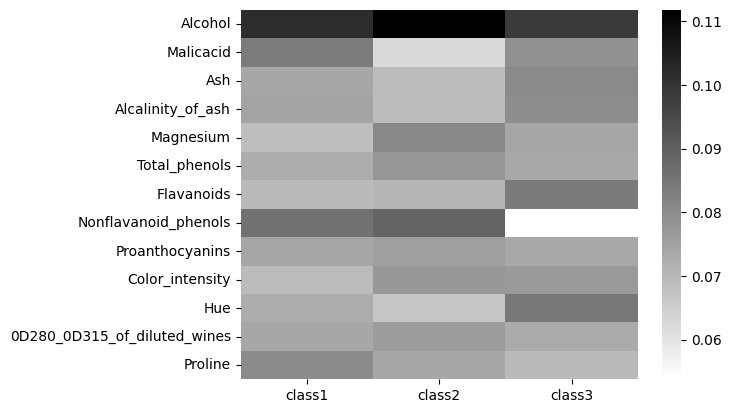

In [846]:
#heat map
W_hat = multiclass_model.weights[:-1]
W_hat_t = np.exp(W_hat)
# Convert W_hat_transformed to a NumPy array before performing the division
W_hat_t = W_hat_t / W_hat_t.sum(axis=0)[None,:]

feature_names = X_wine.columns
label_names = ['class1', 'class2', 'class3']

W_hat_transformed_df = pd.DataFrame(W_hat_t, columns=label_names, index=feature_names)
hmp = heatmap(W_hat_transformed_df, cmap='gray_r')
fig = hmp.get_figure()
fig.savefig("wine_W_hat_transformed.png", bbox_inches="tight", dpi=300)

#Task 3: Implement Logistic and Multiclass classifiers

## Implement Logistic Regression using Breast Cancer Dataset:

In [847]:
class LogisticRegression:

    def __init__(self, add_bias=True, learning_rate=.01, epsilon=1e-4, max_iters=1500, verbose=False):
        self.add_bias = add_bias
        self.learning_rate = learning_rate
        self.epsilon = epsilon                        #to get the tolerance for the norm of gradients
        self.max_iters = max_iters                    #maximum number of iteration of gradient descent
        self.verbose = verbose
        self.val_auroc_history = []
        self.loss_history = []
        self.best_auroc = 0
        self.best_weights = None



    def logistic(self, z):
        return 1 / (1 + np.exp(-z))
        yh = 1/(1+np.exp(-x * w))


    def gradient(self, x, y):
        N,D = x.shape
        yh = self.logistic(np.dot(x, self.w))    # predictions  size N

        grad = np.dot(x.T, yh - y)/N        # divide by N because cost is mean over N points
        #l2: grad += self.lambda_l2 * self.w
        a = np.dot(x, self.w)
        loss = np.sum(y * self.stable_log1pexp(-a) + (1 - y) * self.stable_log1pexp(a)) / N
        #L2: reg_loss = (self.lambda_l2 / 2) * np.sum(self.w ** 2)
        #print("Predicted probabilities (yh):", yh)

        return grad, loss #L2:  + reg_loss

    def fit(self, X_train, y_train, X_val, y_val, X_num_columns):
        if X_train.ndim == 1:
            X_train = X_train[:, None]
        if self.add_bias and X_train.shape[1] == X_num_columns:
            N = X_train.shape[0]
            X_train = np.column_stack([X_train, np.ones(N)])

        N, D = X_train.shape
        self.w = np.random.randn(D) * 0.01
        g = np.inf
        t = 0
        y_train = np.array(y_train).flatten()

        while np.linalg.norm(g) > self.epsilon and t < self.max_iters:
            g, loss = self.gradient(X_train, y_train)
            self.w -= self.learning_rate * g
            self.loss_history.append(loss)

            # Compute validation AUROC every 100 iterations
            if t % 100 == 0:
                y_val_probs = self.predict(X_val, X_num_columns)
                fpr, tpr, _ = roc_curve(y_val, y_val_probs)
                val_auroc = auc(fpr, tpr)
                self.val_auroc_history.append(val_auroc)

                print(f"Iteration {t}: Loss = {loss:.4f}, Validation AUROC = {val_auroc:.4f}")

                # Save the best weights if AUROC improves
                if val_auroc > self.best_auroc:
                    self.best_auroc = val_auroc
                    self.best_weights = self.w.copy()

            t += 1

        # Load the best weights before returning
        if self.best_weights is not None:
            self.w = self.best_weights


        if self.verbose:
            print(f'terminated after {t} iterations, with norm of the gradient equal to {np.linalg.norm(g)}')
            print(f'the weight found: {self.w}')

        return self

    def predict(self, x, X_num_columns):
        if x.ndim == 1:
            x = x[:, None]
        Nt = x.shape[0]
        if self.add_bias and x.shape[1] == X_num_columns:
            x = np.column_stack([x,np.ones(Nt)])
        yh = self.logistic(np.dot(x,self.w))            #predict output
        #print(f"Predicted probabilities (yh): {yh}")
        return yh


    def stable_log1pexp(self, x):
        return np.where(x > 0, x + np.log1p(np.exp(-x)), np.log1p(np.exp(x)))

    def gradient_check(self, x, y, epsilon=1e-5):
        """ Performs gradient checking by computing numerical and analytical gradients without using compute_cost(). """
        w0 = self.w.copy()  # Store the original weights
        num_grad = np.zeros_like(self.w)  # Numerical gradient storage


        for i in range(len(self.w)):  # Loop over each weight
            w_plus = w0.copy()
            w_minus = w0.copy()

            w_plus[i] += epsilon  # Perturb w[i] positively
            w_minus[i] -= epsilon  # Perturb w[i] negatively

            # Compute logits
            a1 = np.dot(x, w_plus)  # Linear activation for w+
            a2 = np.dot(x, w_minus)  # Linear activation for w-


            # Compute cross-entropy loss
            ce1 = np.sum(y * np.log1p(np.exp(-a1)) + (1-y) * np.log1p(np.exp(a1)))
            ce2 = np.sum(y * np.log1p(np.exp(-a2)) + (1-y) * np.log1p(np.exp(a2)))


            N = x.shape[0]

            # Compute numerical gradient
            num_grad[i] = (ce1 - ce2) / (2 * epsilon * N)
            #print(f"Numerical Gradient for w[{i}]: {num_grad[i]}")

        # Compute analytical gradient
        analytical_grad, _ = self.gradient(x, y)
        #print("Analytical Gradient:", analytical_grad)

        print(analytical_grad - num_grad[0])

        # Compute relative difference
        diff = np.linalg.norm(analytical_grad - num_grad) / (np.linalg.norm(analytical_grad) + np.linalg.norm(num_grad) + 1e-10)

        print(f"Gradient difference: {diff:.10f}")

        return diff, num_grad, analytical_grad



In [848]:
#run the following only once!
X_num_columns = X_train_bc_scaled.shape[1]

In [849]:
logistic_reg = LogisticRegression(verbose=True)
mean_x = np.mean(X_test_bc_scaled, axis=0)
std_x = np.std(X_test_bc_scaled, axis=0)
print(X_num_columns)
fit = logistic_reg.fit(X_train_bc_scaled, np.array(y_train_bc).flatten(), X_val_bc_scaled, np.array(y_val_bc).flatten(), X_num_columns)
y_train_pred_bc = fit.predict(X_train_bc_scaled, X_num_columns)
y_test_pred_bc = fit.predict(X_test_bc_scaled, X_num_columns)

# threshold probabilities
y_train_pred_bc = (y_train_pred_bc > 0.5).astype(int)
y_test_pred_bc = (y_test_pred_bc > 0.5).astype(int)

print(y_train_pred_bc.shape)
y_train_bc = np.array(y_train_bc).ravel()
y_test_bc = np.array(y_test_bc).ravel()
print(y_train_bc.shape)

# accuracy = correctly classified / total classified
acc_train = sum(np.array(y_train_pred_bc).flatten()==y_train_bc)/len(y_train_bc)
acc_test = sum(np.array(y_test_pred_bc).flatten()==y_test_bc)/len(y_test_bc)
print(f"train accuracy: {acc_train:.3f}; test accuracy: {acc_test:.3f}")



30
Iteration 0: Loss = 0.6731, Validation AUROC = 0.9558
Iteration 100: Loss = 0.2540, Validation AUROC = 0.9953
Iteration 200: Loss = 0.1911, Validation AUROC = 0.9959
Iteration 300: Loss = 0.1626, Validation AUROC = 0.9965
Iteration 400: Loss = 0.1458, Validation AUROC = 0.9965
Iteration 500: Loss = 0.1345, Validation AUROC = 0.9971
Iteration 600: Loss = 0.1263, Validation AUROC = 0.9971
Iteration 700: Loss = 0.1200, Validation AUROC = 0.9976
Iteration 800: Loss = 0.1149, Validation AUROC = 0.9976
Iteration 900: Loss = 0.1108, Validation AUROC = 0.9976
Iteration 1000: Loss = 0.1073, Validation AUROC = 0.9976
Iteration 1100: Loss = 0.1043, Validation AUROC = 0.9976
Iteration 1200: Loss = 0.1017, Validation AUROC = 0.9976
Iteration 1300: Loss = 0.0995, Validation AUROC = 0.9976
Iteration 1400: Loss = 0.0975, Validation AUROC = 0.9976
terminated after 1500 iterations, with norm of the gradient equal to 0.04127712495956076
the weight found: [ 0.33866593  0.28471374  0.35014524  0.3411815

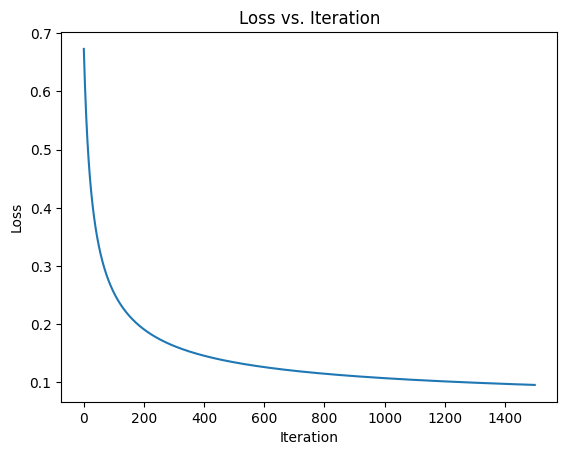

In [850]:
#plot loss

plt.plot(fit.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss vs. Iteration')
plt.show()

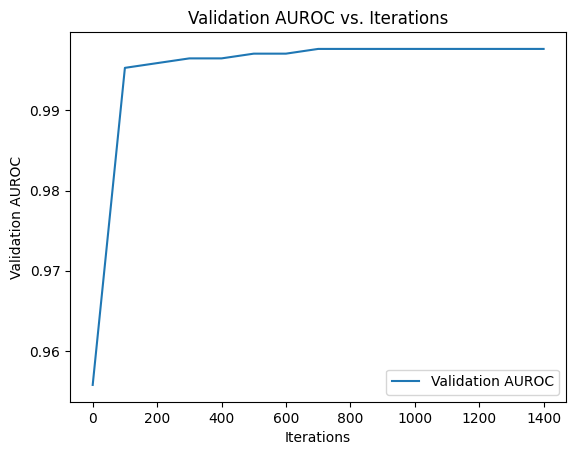

In [851]:
#plot validation auroc
plt.plot(range(0, len(logistic_reg.val_auroc_history) * 100, 100), logistic_reg.val_auroc_history, label="Validation AUROC")
plt.xlabel("Iterations")
plt.ylabel("Validation AUROC")
plt.title("Validation AUROC vs. Iterations")
plt.legend()
plt.show()

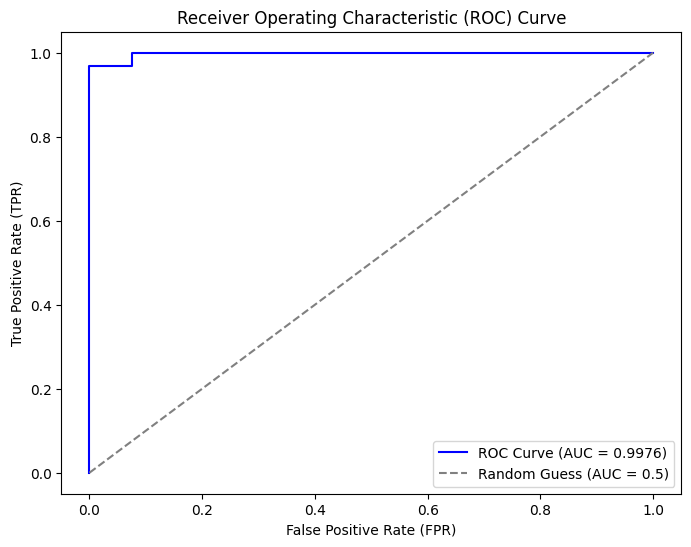

In [852]:
# Get model predictions (probabilities) on validation set
y_val_probs = logistic_reg.predict(X_val_bc_scaled, X_num_columns)

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, _ = roc_curve(y_val_bc, y_val_probs)

# Compute AUROC value
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

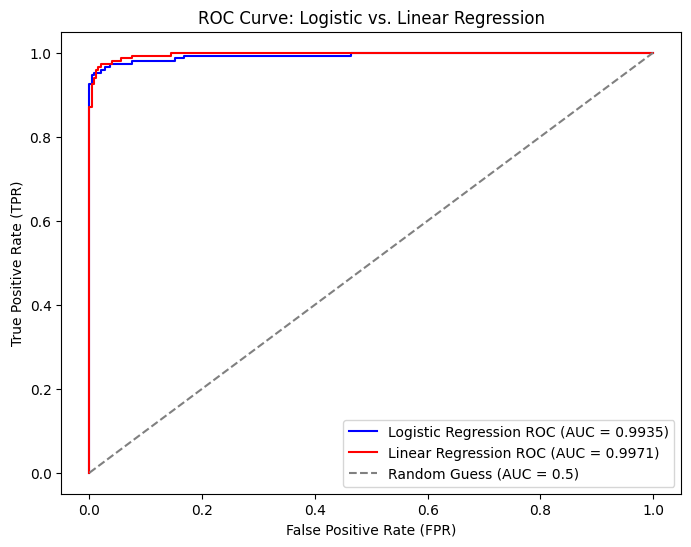

In [853]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assume y_test_bc contains the true binary labels (0/1)
# and that you have computed:
#   y_test_probs (from logistic regression)
#   y_test_probs_lr (from linear regression, after applying sigmoid to raw predictions)

# Get model predictions (probabilities) on test set
y_train_probs = logistic_reg.predict(X_train_bc_scaled, X_num_columns)
y_train_probs_lr = sigmoid(binary_model.predict(X_train_bc_scaled))

# Compute ROC for Logistic Regression on test set
fpr_log, tpr_log, _ = roc_curve(y_train_bc, y_train_probs)
roc_auc_log = auc(fpr_log, tpr_log)

# Compute ROC for Linear Regression on test set
fpr_lr, tpr_lr, _ = roc_curve(y_train_bc, y_train_probs_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plot both ROC curves on the same figure
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color="blue", label=f"Logistic Regression ROC (AUC = {roc_auc_log:.4f})")
plt.plot(fpr_lr, tpr_lr, color="red", label=f"Linear Regression ROC (AUC = {roc_auc_lr:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: Logistic vs. Linear Regression")
plt.legend()
plt.show()

In [854]:
#gradient check

if logistic_reg.add_bias and X_train_bc_scaled.shape[1] < X_num_columns+1:
    X_train_bc_scaled = np.column_stack([X_train_bc_scaled, np.ones(X_train_bc_scaled.shape[0])])

diff, num_grad, analytical_grad = logistic_reg.gradient_check(X_train_bc_scaled, np.array(y_train_bc).flatten())
print(f"Gradient difference: {diff:.10f}")

[ 5.16982290e-13 -6.07995790e-03  4.53701038e-04 -7.94801551e-04
  7.27061220e-03  1.51463913e-02  4.25476773e-03 -9.20614578e-04
  1.21720564e-02  2.24119511e-02 -3.99285028e-03  1.19148361e-02
  5.23135343e-04 -1.77446007e-03  1.10007184e-02  2.79259921e-02
  2.10901774e-02  1.38561426e-02  1.78253836e-02  2.61824623e-02
 -4.90756029e-03 -1.19560949e-02 -3.33430984e-03 -4.74561501e-03
 -8.69260037e-04  1.20170566e-02  4.89670230e-03 -8.16622700e-06
 -2.38759871e-03  1.23213709e-02  3.13969961e-02]
Gradient difference: 0.0000000001
Gradient difference: 0.0000000001


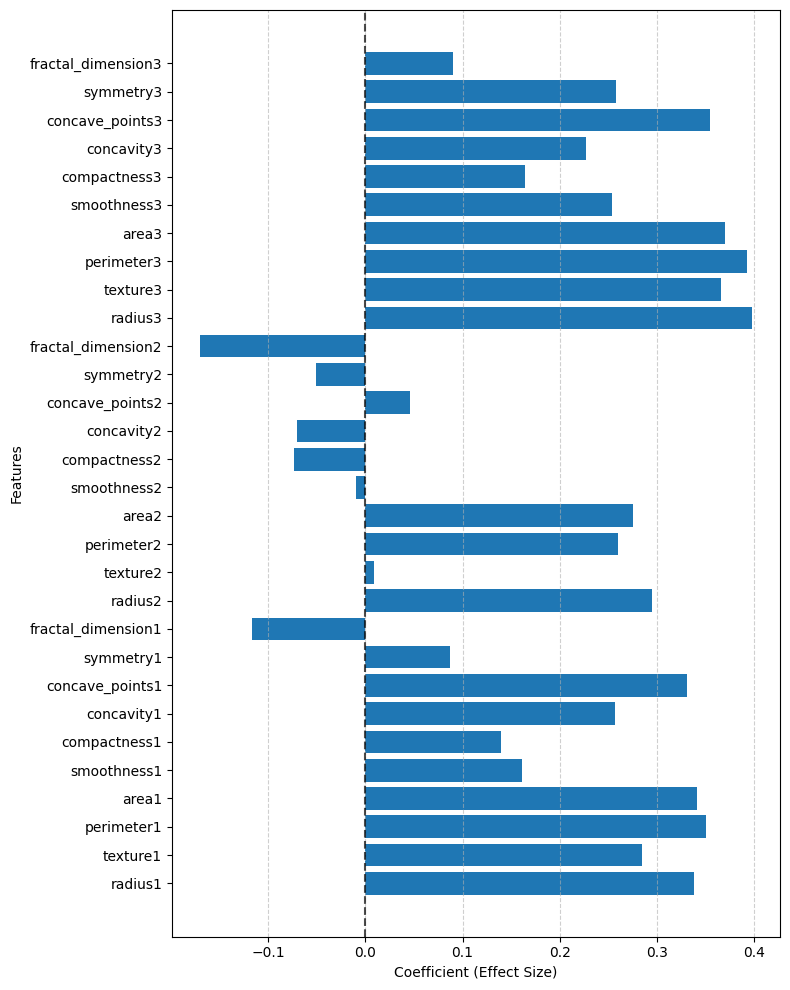

In [855]:
#coefficients effect size barplot
effect_size = pd.DataFrame({
    "Feature": X_train_bc.columns,  # Feature names
    "Coefficient": fit.w[:-1]  # Corresponding effect sizes
})

plt.figure(figsize=(8, 10))
plt.barh(effect_size["Feature"], effect_size["Coefficient"], align='center')
plt.xlabel("Coefficient (Effect Size)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)  # Reference line at zero
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Implementing Multiclass Logistic Regression using Wine Recognition dataset:

In [856]:
class Multinomial_logistic:
    def __init__(self, nFeatures, nClasses):
        self.W = np.random.rand(nFeatures, nClasses)

    def predict(self, X):
        y_pred = np.exp(np.matmul(X, self.W))
        return y_pred / y_pred.sum(axis=1).reshape(X.shape[0], 1)

    def grad(self, X, y):
        return np.matmul(X.transpose(), self.predict(X) - y)

    def ce(self, X, y):
        return -np.sum(y * np.log(self.predict(X)))

    # modified to compute best validation accuracy as well in order to to determine the best number of iterations
    def fit(self, X, y, X_valid=None, y_valid=None, lr=0.005, niter=100):
        losses_train = np.zeros(niter)
        losses_valid = np.zeros(niter)
        auroc_valid = np.zeros(niter)
        acc_valid = np.zeros(niter)

        for i in range(niter):
            self.W -= lr * self.grad(X, y)
            losses_train[i] = self.ce(X, y)

            if X_valid is not None and y_valid is not None:
                losses_valid[i] = self.ce(X_valid, y_valid)
                y_valid_pred = self.predict(X_valid)

                # Compute Accuracy
                acc_valid[i] = accuracy_score(y_valid.argmax(axis=1), y_valid_pred.argmax(axis=1))

                print(f"iter {i}: loss_train={losses_train[i]:.3f}, loss_valid={losses_valid[i]:.3f}, validation_acc={acc_valid[i]:.3f}")
            else:
                print(f"iter {i}: loss_train={losses_train[i]:.3f}")

        return losses_train, losses_valid, acc_valid

    def fit2(self, X, y, X_valid=None, y_valid=None, lr=0.005, niter=100):
        losses_train = np.zeros(niter)
        losses_valid = np.zeros(niter)
        acc_valid = np.zeros(niter)

        best_acc = -1  # Initialize best accuracy as a very low value
        best_W = self.W.copy()  # Store best weight matrix

        for i in range(niter):
          self.W -= lr * self.grad(X, y)
          losses_train[i] = self.ce(X, y)

          if X_valid is not None and y_valid is not None:
              losses_valid[i] = self.ce(X_valid, y_valid)
              y_valid_pred = self.predict(X_valid)

              # Compute Accuracy
              acc_valid[i] = accuracy_score(y_valid.argmax(axis=1), y_valid_pred.argmax(axis=1))

              # Check if current accuracy is the best so far
              if acc_valid[i] > best_acc:
                best_acc = acc_valid[i]
                best_W = self.W.copy()  # Save the best weights

              print(f"iter {i}: loss_train={losses_train[i]:.3f}, loss_valid={losses_valid[i]:.3f}, validation_acc={acc_valid[i]:.3f}")
          else:
              print(f"iter {i}: loss_train={losses_train[i]:.3f}")

        # Restore best weights
        self.W = best_W

        print(f"Best validation accuracy: {best_acc:.3f}")
        return losses_train, losses_valid, acc_valid


    #this function
    def check_grad(self, X, y):
        N, C = y.shape
        D = X.shape[1]

        diff = np.zeros((D, C))

        W = self.W.copy()

        for i in range(D):
            for j in range(C):
                epsilon = np.zeros((D, C))
                epsilon[i, j] = np.random.rand() * 1e-4

                self.W = self.W + epsilon
                J1 = self.ce(X, y)
                self.W = W

                self.W = self.W - epsilon
                J2 = self.ce(X, y)
                self.W = W

                numeric_grad = (J1 - J2) / (2 * epsilon[i, j])
                derived_grad = self.grad(X, y)[i, j]

                diff[i, j] = np.square(derived_grad - numeric_grad).sum() / \
                             np.square(derived_grad + numeric_grad).sum()

        # print(diff)
        return diff.sum()


1.2295133465705904e-15
iter 0: loss_train=49.715, loss_valid=29.931, validation_acc=0.727
iter 1: loss_train=33.766, loss_valid=21.208, validation_acc=0.841
iter 2: loss_train=25.972, loss_valid=16.756, validation_acc=0.886
iter 3: loss_train=21.395, loss_valid=14.084, validation_acc=0.886
iter 4: loss_train=18.387, loss_valid=12.316, validation_acc=0.932
iter 5: loss_train=16.253, loss_valid=11.060, validation_acc=0.932
iter 6: loss_train=14.653, loss_valid=10.122, validation_acc=0.932
iter 7: loss_train=13.403, loss_valid=9.393, validation_acc=0.977
iter 8: loss_train=12.398, loss_valid=8.810, validation_acc=0.977
iter 9: loss_train=11.568, loss_valid=8.332, validation_acc=0.977
iter 10: loss_train=10.871, loss_valid=7.932, validation_acc=0.977
iter 11: loss_train=10.274, loss_valid=7.592, validation_acc=0.977
iter 12: loss_train=9.758, loss_valid=7.299, validation_acc=0.977
iter 13: loss_train=9.305, loss_valid=7.043, validation_acc=0.977
iter 14: loss_train=8.905, loss_valid=6.816,

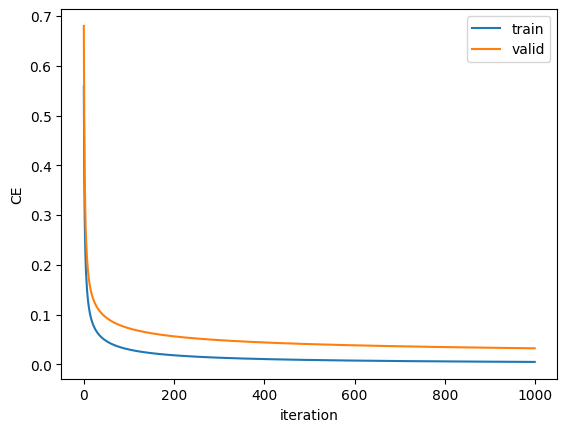

In [857]:
N, C = (y_train_wine.shape)

X_train = np.c_[X_train_wine_scaled, np.ones(N)] # add one column to learn the linear intercept

X_valid = np.c_[X_val_wine_scaled, np.ones(X_val_wine_scaled.shape[0])]

X_test = np.c_[X_test_wine_scaled, np.ones(X_test_wine_scaled.shape[0])]

D = X_train.shape[1]

#convert the y values to np arrays
y_train_wine = np.array(y_train_wine)
y_valid_wine = np.array(y_val_wine)
y_test_wine = np.array(y_test_wine)

#INITIALIZE THE MODEL
mlr = Multinomial_logistic(D, C)

#print(mlr.predict(X_train)[:5])

# check gradients with small perturbation approach
print(mlr.check_grad(X_train, y_train_wine))

ce_train, ce_valid, acc_valid = mlr.fit(X_train, y_train_wine, X_valid, y_valid_wine, niter=1000)


#PLOT
plt.clf()
plt.plot(ce_train/X_train_wine.shape[0], label='train')
plt.plot(ce_valid/X_val_wine.shape[0], label='valid')
plt.xlabel("iteration")
plt.ylabel("CE")
plt.legend()
# plt.show()
plt.savefig("training_ce.png", bbox_inches="tight", dpi=300)



In [858]:
# check gradients with small perturbation approach
print(mlr.check_grad(X_train, y_train_wine))

1.8381663192074721e-16


Best Iteration (based on validation accuracy): 7


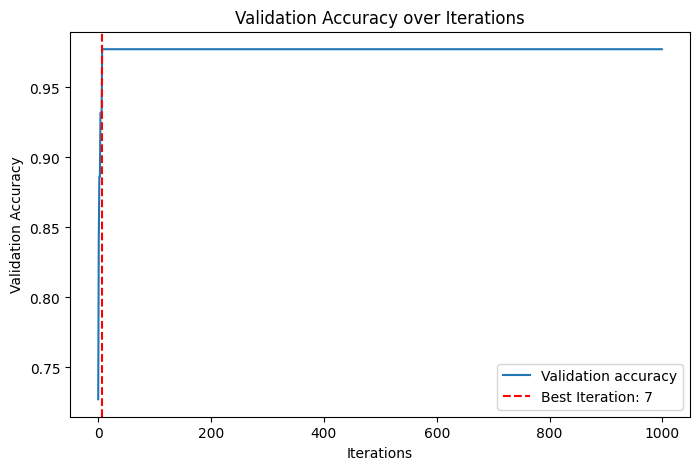

In [859]:
optimal_niter_acc = np.argmax(acc_valid)
print(f"Best Iteration (based on validation accuracy): {optimal_niter_acc}")

# Plot Validation AUROC per Iteration
plt.figure(figsize=(8, 5))
plt.plot(range(len(acc_valid)), acc_valid, label="Validation accuracy")
plt.axvline(optimal_niter_acc, color='r', linestyle='--', label=f"Best Iteration: {optimal_niter_acc}")
plt.xlabel("Iterations")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy over Iterations")
plt.legend()
plt.show()

In [860]:
#RETRAIN MODEL USING BEST NUMBER OF ITERATIONS

mlr = Multinomial_logistic(D, C)
optimal_niter = ce_valid.argmin()
print(optimal_niter)
_, _,_ = mlr.fit(X_train, y_train_wine, niter=optimal_niter)

999
iter 0: loss_train=50.457
iter 1: loss_train=36.244
iter 2: loss_train=28.628
iter 3: loss_train=23.846
iter 4: loss_train=20.579
iter 5: loss_train=18.214
iter 6: loss_train=16.425
iter 7: loss_train=15.024
iter 8: loss_train=13.896
iter 9: loss_train=12.967
iter 10: loss_train=12.189
iter 11: loss_train=11.525
iter 12: loss_train=10.952
iter 13: loss_train=10.451
iter 14: loss_train=10.009
iter 15: loss_train=9.615
iter 16: loss_train=9.261
iter 17: loss_train=8.942
iter 18: loss_train=8.651
iter 19: loss_train=8.385
iter 20: loss_train=8.140
iter 21: loss_train=7.914
iter 22: loss_train=7.705
iter 23: loss_train=7.510
iter 24: loss_train=7.328
iter 25: loss_train=7.157
iter 26: loss_train=6.997
iter 27: loss_train=6.846
iter 28: loss_train=6.703
iter 29: loss_train=6.568
iter 30: loss_train=6.440
iter 31: loss_train=6.318
iter 32: loss_train=6.202
iter 33: loss_train=6.091
iter 34: loss_train=5.986
iter 35: loss_train=5.885
iter 36: loss_train=5.788
iter 37: loss_train=5.695
ite

In [861]:
def evaluate(y, y_pred):
    accuracy = sum(y_pred.argmax(axis=1) == y.argmax(axis=1))
    accuracy = accuracy / y.shape[0]
    return accuracy


train_accuracy = evaluate(y_train_wine, mlr.predict(X_train))
valid_accuracy = evaluate(y_valid_wine, mlr.predict(X_valid))
test_accuracy = evaluate(y_test_wine, mlr.predict(X_test))

print(train_accuracy)
print(valid_accuracy)
print(test_accuracy)

1.0
1.0
0.9777777777777777


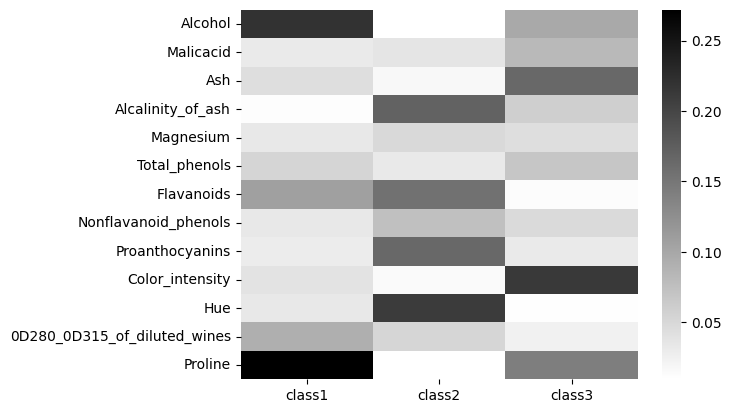

In [862]:
#heat map
W_hat = mlr.W[:-1,:] # remove the intercept
W_hat_transformed = np.exp(W_hat)
#do the softmax to transform the coefficient to give you a transformed w hat. High probabilities indicate close to causal for a class.
W_hat_transformed = W_hat_transformed / W_hat_transformed.sum(axis=0)[None,:]

feature_names = X_wine.columns
label_names = ['class1', 'class2', 'class3']

W_hat_transformed_df = pd.DataFrame(W_hat_transformed, columns=label_names, index=feature_names)
hmp = heatmap(W_hat_transformed_df, cmap='gray_r')
fig = hmp.get_figure()
fig.savefig("wine_W_hat_transformed.png", bbox_inches="tight", dpi=300)

# COMPARING



In [863]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression as sk_LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = [KNeighborsClassifier(),
          DecisionTreeClassifier(),]

perf = {}

# our implementation is slow you may try sklearn version
#logitreg = LogisticRegression(max_iters=1e3)
#fit = logitreg.fit(X_train, y_train)
#y_test_prob = fit.predict(X_test)
#fpr, tpr, _ = roc_curve(y_test, y_test_prob)
#auroc = roc_auc_score(y_test, y_test_prob)
#perf["LogisticRegression (ours)"] = {'fpr':fpr, 'tpr':tpr, 'auroc':auroc}

for model in models:
    fit = model.fit(X_train_bc_scaled, y_train_bc)
    y_test_prob = fit.predict_proba(X_test_bc_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test_bc, y_test_prob)
    auroc = roc_auc_score(y_test_bc, y_test_prob)
    if type(model).__name__ == "LogisticRegression":
        perf["LogisticRegression (sklearn)"] = {'fpr':fpr,'tpr':tpr,'auroc':auroc}
    else:
        perf[type(model).__name__] = {'fpr':fpr,'tpr':tpr,'auroc':auroc}


plt.clf()
i = 0
for model_name, model_perf in perf.items():
    plt.plot(model_perf['fpr'], model_perf['tpr'],label=model_name)
    plt.text(0.4, i+0.1, model_name + ': AUC = '+ str(round(model_perf['auroc'],2)))
    i += 0.1

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC in Breast Cancer')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="upper left")
# plt.show()
plt.savefig("roc_curve.png", bbox_inches='tight', dpi=300)
# plt.close()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


ValueError: X has 30 features, but KNeighborsClassifier is expecting 31 features as input.